In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

In [2]:
data = pd.read_parquet('../data/interim/meteorological_data_with_outages.parquet')
data.drop_duplicates(inplace=True)

In [3]:
train_episode_fips_id, test_episode_fips_id = train_test_split(
    data.episode_fips_id.unique(), train_size=0.7, random_state=42
)

In [6]:
drop_cols = ['time', 'episode_fips_id', 'meteorological_current_datetime_val']

data_train = data[data.episode_fips_id.isin(train_episode_fips_id)].drop(drop_cols, axis=1)
data_test = data[data.episode_fips_id.isin(test_episode_fips_id)].drop(drop_cols, axis=1)

In [7]:
x_train, y_train = data_train.drop('outage_in_an_hour', axis=1), data_train.outage_in_an_hour
x_test, y_test = data_test.drop('outage_in_an_hour', axis=1), data_test.outage_in_an_hour

In [8]:
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced',
    ccp_alpha=0.001, 
)

In [9]:
model.fit(x_train, y_train)

RandomForestClassifier(ccp_alpha=0.001, class_weight='balanced', max_depth=12)

In [10]:
pred_train = pd.Series(model.predict_proba(x_train)[:, 1])
pred_train.index = x_train.index

In [11]:
pred_test = pd.Series(model.predict_proba(x_test)[:, 1])
pred_test.index = x_test.index

In [12]:
roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_test)

(np.float64(0.8141876871923269), np.float64(0.7878974208908822))

In [49]:
pred_test

episode_fips_time_id
100298_36075_2015081813    0.328680
100298_36075_2015081814    0.321037
100298_36075_2015081815    0.335458
100298_36075_2015081816    0.400405
100298_36075_2015081817    0.511311
                             ...   
99962_34029_2015101019     0.280041
99962_34029_2015101020     0.279056
99962_34029_2015101021     0.275469
99962_34029_2015101022     0.279016
99962_34029_2015101023     0.280307
Length: 110959, dtype: float64

In [50]:
precision, recall, _ = precision_recall_curve(y_test, pred_test)
auc(recall, precision)

np.float64(0.0659322005778921)

In [51]:
precision, recall, _ = precision_recall_curve(y_test, pred_test)
auc(recall, precision)

np.float64(0.0659322005778921)

(array([11.,  5.,  4.,  6.,  8.,  7.,  2., 11.,  8.,  3.,  6.,  1.,  6.,
         8.,  6.,  7., 12.,  7.,  9.,  9.,  8.,  5.,  6.,  8.,  8.,  6.,
         8.,  6.,  6., 10.,  8.,  8.,  3.,  8.,  9.,  6.,  7.,  9., 13.,
         9.,  8., 12.,  9.,  3.,  9.,  6.,  9., 14.,  8., 11., 11.,  9.,
        22., 20., 11.,  9., 20., 12., 15., 13., 14., 11., 13., 23., 16.,
        13., 21., 20., 16., 25., 16., 22., 18., 11., 26., 12., 26., 19.,
        24., 24., 24., 36., 26., 35., 29., 46., 32., 31., 29., 39., 24.,
        18., 29., 34., 32., 25., 18., 19., 30., 21.]),
 array([0.17044696, 0.17689519, 0.18334341, 0.18979164, 0.19623986,
        0.20268809, 0.20913632, 0.21558454, 0.22203277, 0.22848099,
        0.23492922, 0.24137745, 0.24782567, 0.2542739 , 0.26072212,
        0.26717035, 0.27361858, 0.2800668 , 0.28651503, 0.29296325,
        0.29941148, 0.30585971, 0.31230793, 0.31875616, 0.32520438,
        0.33165261, 0.33810083, 0.34454906, 0.35099729, 0.35744551,
        0.36389374, 0.3703

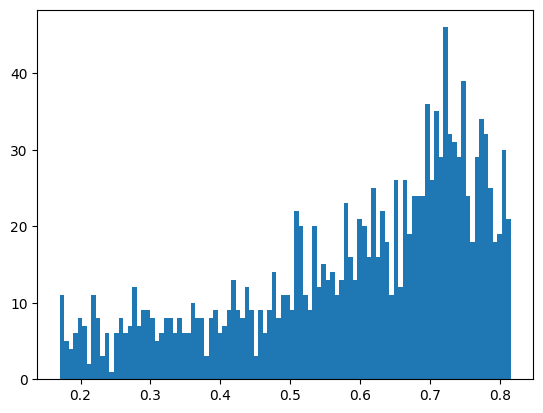

In [14]:
plt.hist(pred_test[y_test==1],bins=100)

(array([ 413., 2118., 1927., 1732., 1852., 1711., 1621., 1526., 1471.,
        1411., 1334., 1248., 1171., 1039., 1025., 1028., 1041., 1026.,
         935.,  984.,  933.,  929.,  834.,  829.,  760.,  710.,  750.,
         744.,  663.,  660.,  663.,  619.,  580.,  580.,  539.,  539.,
         532.,  545.,  469.,  507.,  468.,  414.,  425.,  459.,  426.,
         448.,  429.,  425.,  457.,  402.,  424.,  416.,  437.,  455.,
         494.,  478.,  490.,  451.,  452.,  500.,  415.,  427.,  436.,
         425.,  462.,  485.,  509.,  484.,  427.,  438.,  425.,  451.,
         496.,  461.,  446.,  464.,  449.,  403.,  398.,  428.,  366.,
         426.,  463.,  508.,  419.,  372.,  402.,  304.,  278.,  290.,
         232.,  271.,  234.,  231.,  210.,  158.,  116.,  110.,  123.,
          81.]),
 array([0.16250177, 0.16903226, 0.17556274, 0.18209323, 0.18862371,
        0.1951542 , 0.20168468, 0.20821516, 0.21474565, 0.22127613,
        0.22780662, 0.2343371 , 0.24086759, 0.24739807, 0.25392855

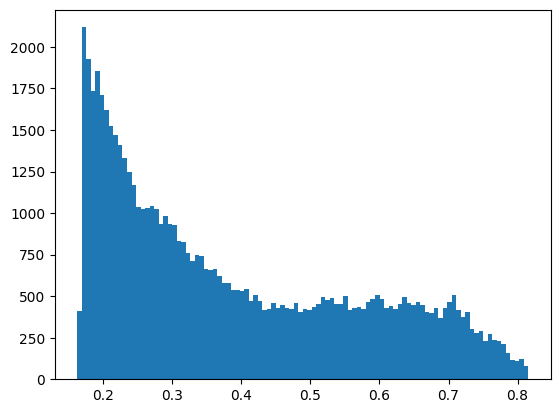

In [15]:
plt.hist(pred_test[y_test==0], bins=100)

In [54]:
response_var = pd.read_parquet('../data/interim/storm_outages_2014_2023.parquet')

In [22]:
sample_id = pd.Series(train_episode_fips_id).sample(1).iloc[0]
sample_data = data[data.episode_fips_id==sample_id]
sample_data['pred'] = pred_train

/tmp/ipykernel_3422/3169872164.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data['pred'] = pred_train


In [23]:
sample_data

,time,T2M,ALLSKY_SFC_SW_DWN,PS,WS50M,ALLSKY_SFC_LW_DWN,WD50M,PRECTOTCORR,GWETPROF,CLRSKY_SFC_SW_DWN,...,Z0M,TOA_SW_DWN,RH2M,WS2M,CLRSKY_SFC_LW_DWN,DISPH,episode_fips_id,meteorological_current_datetime_val,outage_in_an_hour,pred
episode_fips_time_id,,,,,,,,,,,,,,,,,,,,,
166575_27131_2022041212,2022041212,13.58,136.15,96.62,18.42,362.98,124.9,5.08,0.57,810.58,...,0.03,1096.85,43.21,10.17,294.85,0.18,166575_27131,2022-04-12 12:00:00,0.0,0.419586
166575_27131_2022041213,2022041213,13.81,93.65,96.57,17.62,369.15,135.1,10.54,0.57,765.05,...,0.03,1048.25,49.58,9.89,298.95,0.18,166575_27131,2022-04-12 13:00:00,0.0,0.431009
166575_27131_2022041214,2022041214,14.04,73.85,96.48,15.73,374.30,139.6,15.37,0.57,658.25,...,0.03,938.20,58.61,8.95,304.75,0.18,166575_27131,2022-04-12 14:00:00,0.0,0.441154
166575_27131_2022041215,2022041215,13.98,39.40,96.35,14.61,373.98,136.7,10.09,0.57,521.20,...,0.03,774.25,66.74,8.14,308.42,0.18,166575_27131,2022-04-12 15:00:00,0.0,0.449171
166575_27131_2022041216,2022041216,13.75,17.80,96.22,13.76,377.88,130.4,10.59,0.57,351.45,...,0.03,567.58,74.38,7.56,313.50,0.18,166575_27131,2022-04-12 16:00:00,0.0,0.498527
166575_27131_2022041217,2022041217,13.47,43.28,96.10,13.24,377.38,126.1,13.07,0.57,172.60,...,0.03,332.30,82.40,7.07,317.15,0.18,166575_27131,2022-04-12 17:00:00,0.0,0.519415
166575_27131_2022041218,2022041218,13.13,9.43,95.97,13.32,348.17,124.0,12.49,0.57,28.27,...,0.03,87.60,89.89,6.95,325.27,0.18,166575_27131,2022-04-12 18:00:00,1.0,0.573043


In [57]:
pred_train.index.value_counts()

episode_fips_time_id
164119_06029_2021120823    2
108294_55079_2016090719    2
173075_06073_2022090202    2
159399_06029_2021071400    2
182909_48061_2023062311    2
                          ..
152231_06059_2020081904    1
152231_06059_2020081903    1
152231_06059_2020081902    1
152231_06059_2020081901    1
152231_06059_2020081909    1
Name: count, Length: 268453, dtype: int64

In [58]:
data.loc['164119_06029_2021120823']

,time,T2M,ALLSKY_SFC_SW_DWN,PS,WS50M,ALLSKY_SFC_LW_DWN,WD50M,PRECTOTCORR,GWETPROF,CLRSKY_SFC_SW_DWN,...,TQV,Z0M,TOA_SW_DWN,RH2M,WS2M,CLRSKY_SFC_LW_DWN,DISPH,episode_fips_id,meteorological_current_datetime_val,outage_in_an_hour
episode_fips_time_id,,,,,,,,,,,,,,,,,,,,,
164119_06029_2021120823,2021120823,8.91,0.0,92.91,1.78,302.33,233.9,0.84,0.55,0.0,...,20.32,0.1,0.0,90.7,0.5,273.62,0.5,164119_06029,2021-12-08 23:00:00,1.0
164119_06029_2021120823,2021120823,8.91,0.0,92.91,1.78,302.33,233.9,0.84,0.55,0.0,...,20.32,0.1,0.0,90.7,0.5,273.62,0.5,164119_06029,2021-12-08 23:00:00,0.0
